# Somnotate Scoring and Inspection
Score EDF recordings by subject and date, then save predictions.

In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
from utils.scoring import score_recordings
from utils.visualization import plot_scoring_detailed, plot_state_distributions
%matplotlib qt

model_name = "test_model_2"
repo_root = Path.cwd().parent
model_path = (
    repo_root
    / "data"
    / "hypnose_eeg"
    / "derivatives"
    / "somnotate_training"
    / model_name
    / "model.pickle"
)

In [3]:
subjids = [66]
dates = [20260717]
# date_range = (20260501, 20260510)

outputs = score_recordings(
    subjids=subjids,
    dates=dates,
    model_path=model_path,
    repo_root=repo_root,
)

for path in outputs:
    print("Saved predictions:", path)

[sub-066 ses-001 date-20260717] sub-066_ses-001_recording-001_2026-07-17_13_40_01.edf
  Duration: 71.2 h | missing: 34 s (0.0%) | longest gap: 9 s
  Strategy: mask_inline — score the kept range as one chunk, mark middle gaps as undefined post-hoc
  Segments (20):
    [       0 ->    15664 s]  signal     (4.4 h)  (within chunk 1)
    [   15664 ->    15666 s]  gap        (2 s)
    [   15666 ->    15756 s]  signal     (1.5 min)  (within chunk 1)
    [   15756 ->    15760 s]  gap        (4 s)
    [   15760 ->    15928 s]  signal     (2.8 min)  (within chunk 1)
    [   15928 ->    15931 s]  gap        (3 s)
    [   15931 ->    75931 s]  signal     (16.7 h)  (within chunk 1)
    [   75931 ->    75933 s]  gap        (2 s)
    [   75933 ->    75948 s]  signal     (15 s)  (within chunk 1)
    [   75948 ->    75951 s]  gap        (3 s)
    [   75951 ->    94414 s]  signal     (5.1 h)  (within chunk 1)
    [   94414 ->    94417 s]  gap        (3 s)
    [   94417 ->    94419 s]  signal     (2 s)  

# Visualization for Scored Subjects

1. Plot Scoring Detailed: 
- Plots raw EMG, raw EEG, Delta, Theta, T:D Ratio, EMG RMS 
- Plots Somnotate-scored states below
- All in interactive visualizer

2. Plot State Distributions: 
- One plot for: Theta, Delta, T:D Ratio, EMG RMS
- In each, normalized distribution for NREM, REM, and Wake is shown
- Allows to judge if Somnotate scoring is plausible

In [2]:
viz_subjid = "66"
viz_date = "20260717"

In [ ]:
# Visualize a single scored recording (one subject and one date).
# Detailed view: EEG/EMG raw, EMG RMS, delta & theta envelopes, theta:delta ratio,
# plus the somnotate state row. Pass manual_vectors={"scorer": vec, ...} to overlay
# human scorers and shade mismatch regions.
fig, viewer = plot_scoring_detailed(
    subjid=viz_subjid,
    date=viz_date,
    repo_root=repo_root,
    recording_index=0,
    manual_vectors=None,   # optional: {"human": human_vec}
    eeg_channel=0,
    view_length_s=120.0,
)


Loading sub-066_ses-001_recording-001_2026-07-17_13_40_01.edf…
Computing metrics for sub-066_ses-001_recording-001_2026-07-17_13_40_01.edf…

[sub-066 date-20260717] sub-066_ses-001_recording-001_2026-07-17_13_40_01.edf
State occupancy (of 256206 scored Wake/NREM/REM 1s epochs):
  Wake :  46.9%   (24007 analysis epochs of 5s)
  NREM :  47.3%   (24262 analysis epochs of 5s)
  REM  :   5.8%   (2971 analysis epochs of 5s)


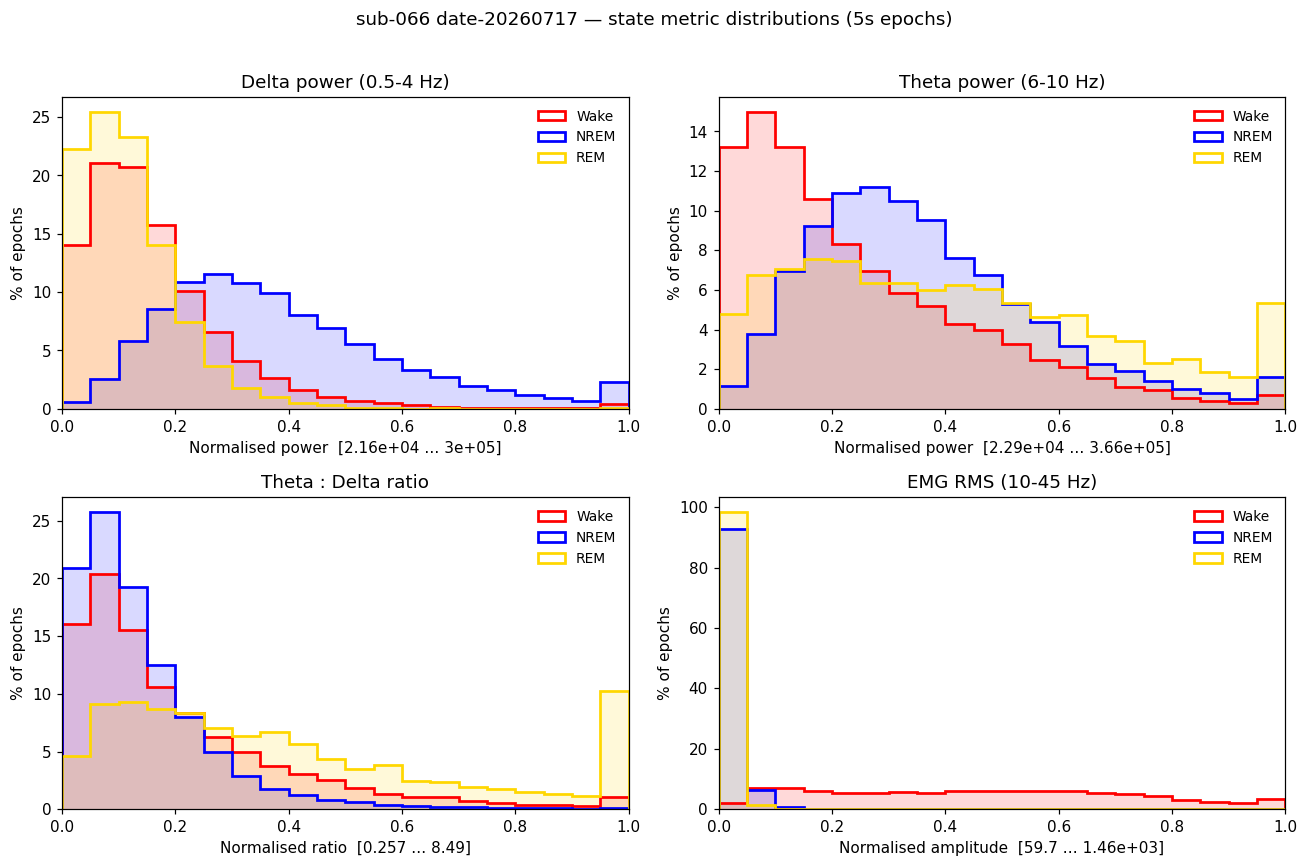

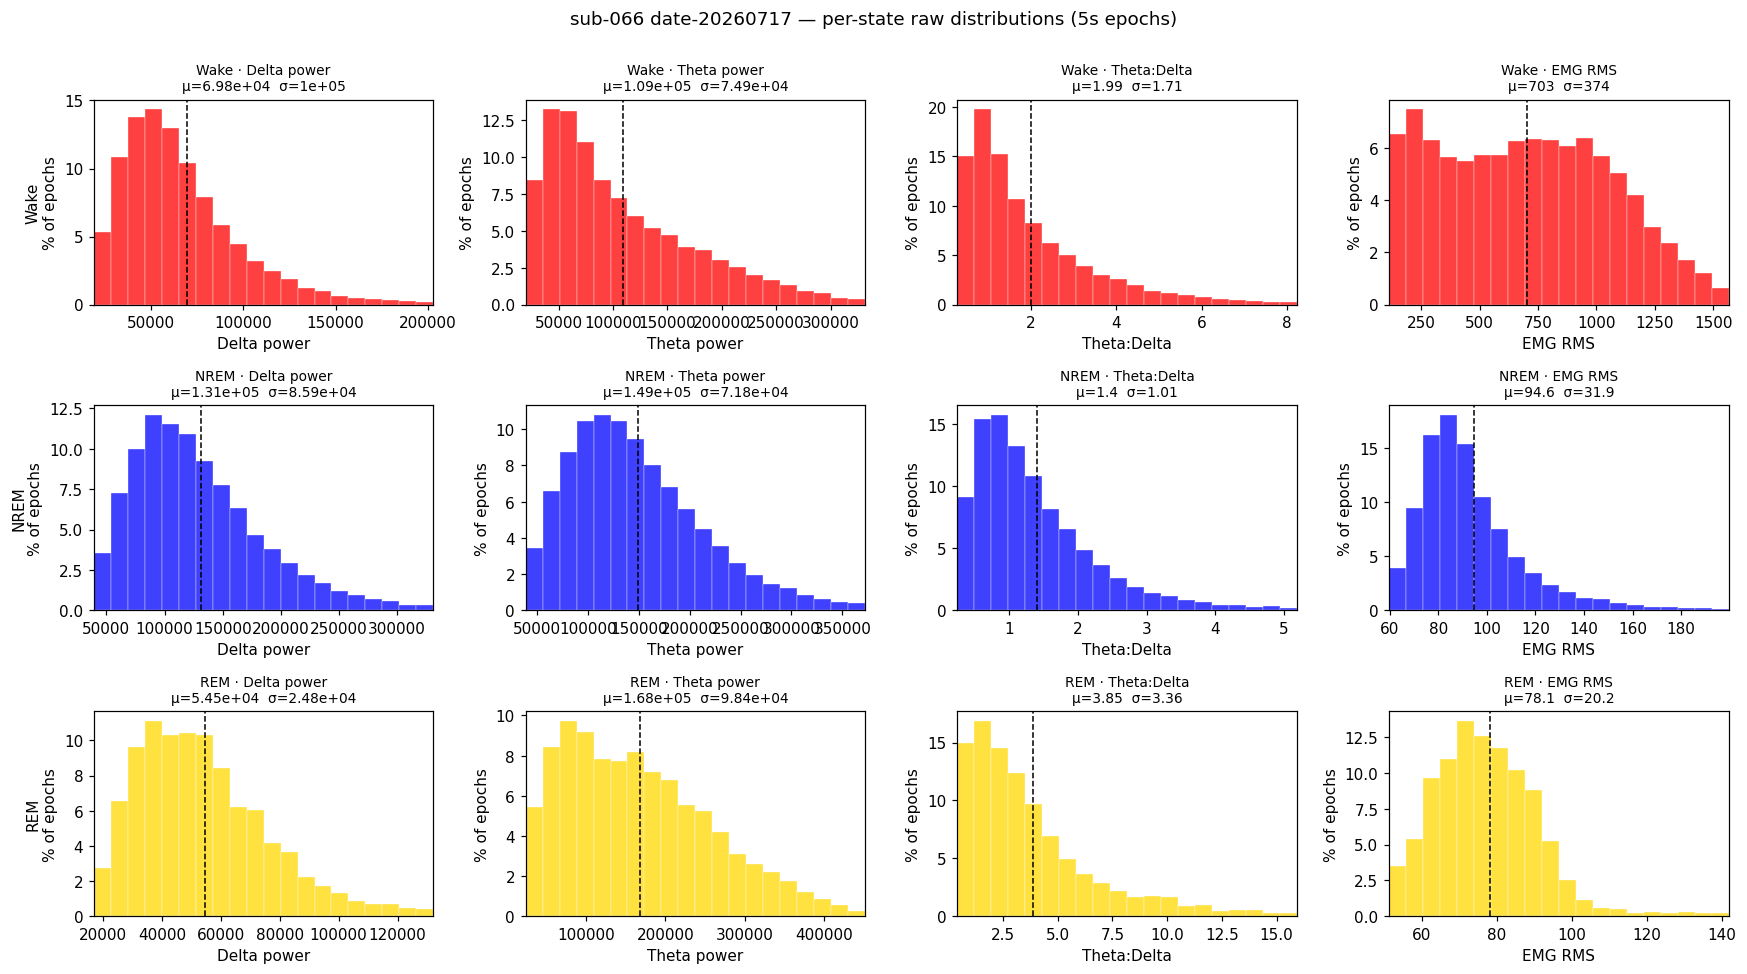

In [ ]:
# Per-state metric distributions for one scored recording.
# Splits the recording into Wake/NREM/REM, stitches each state's signal, epochs it
# (epoch_length_s), and histograms delta power, theta power, theta:delta ratio, and
# EMG RMS per state (Wake=red, NREM=blue, REM=yellow). Prints time spent per state.
sessions = plot_state_distributions(
    subjid=viz_subjid,
    date=viz_date,
    repo_root=repo_root,
    epoch_length_s=5.0,
    bin_width=0.05, #Resolution of bins on x axis
    save=True,
)
